<a href="https://colab.research.google.com/github/nadiahsnkaff/Python/blob/main/Hybrid_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# to handle datasets
import pandas as pd
import numpy as np

# to divide train and test set
from sklearn.model_selection import train_test_split

# feature scaling
from sklearn.preprocessing import StandardScaler, FunctionTransformer

# create pipeline
from sklearn.pipeline import Pipeline

# PCA
from sklearn.decomposition import PCA

# Information Gain
from sklearn.feature_selection import mutual_info_classif, SelectPercentile

# Lasso
from sklearn.linear_model import LassoCV

# visualization
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load dataset
df=pd.read_csv('/content/drive/MyDrive/PythonProject/Breast_GSE70947.csv')
df.head()

,type,NM_144987,NM_013290,ENST00000322831,NM_001625,lincRNA:chr7:226042-232442_R,NM_032391,ENST00000238571,XR_108906,NM_005937,...,NM_207327,NM_001004477,NM_020700,NM_005895,NM_000679,NR_003529,NR_036446,NM_001001957,lincRNA:chr7:29652000-29661000_R,ENST00000494108
0,0,8.693318,7.718016,6.044438,10.747077,9.133777,4.735581,5.634732,4.670231,11.152649,...,10.453202,4.376090,5.597596,11.860087,11.321528,4.486530,5.489959,5.810069,4.834056,4.383929
1,0,9.375980,7.072232,6.976741,10.429671,9.526500,5.221089,5.425187,4.860931,10.839289,...,10.066372,4.383785,5.404546,11.636828,8.283747,4.770318,5.345571,4.457930,4.441395,4.411587
2,0,8.943442,7.964573,6.269055,10.825025,9.396855,5.258506,5.824921,4.964604,10.884157,...,10.380676,4.428892,5.356374,12.031338,9.420630,4.394069,5.851030,4.508072,4.568262,4.316081
3,0,9.020798,7.824639,6.165165,11.646788,8.776462,4.648655,6.676692,4.770186,10.646459,...,10.509871,4.381542,5.757179,11.944607,10.311339,4.451118,6.117379,4.505663,4.413361,4.537626
4,0,8.806154,7.555348,6.230969,11.635247,8.911383,4.518054,6.520691,4.540453,10.939783,...,10.552841,4.386116,6.851058,11.976510,10.904219,4.432566,6.286439,4.540453,4.412933,4.452250


In [ ]:
df.shape

(289, 16383)

In [ ]:
target_name = 'type'

#separate object for target feature
y = df[target_name]

#separate object for input feature
X = df.drop(target_name, axis=1)

In [ ]:
#split the dataset into training set and test set

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    # we are setting the seed here
                                                    random_state=0)

X_train.shape, X_test.shape

((202, 16382), (87, 16382))

In [ ]:
X_test.shape, y_test.shape

((87, 16382), (87,))

In [ ]:
# feature scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### PCA

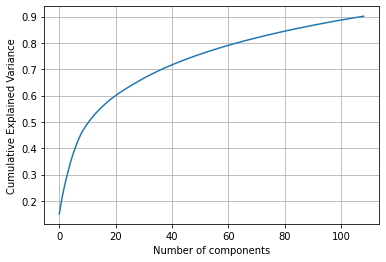

In [ ]:
# reduce dimension using PCA
# verify n components
pca_test = PCA(0.90, random_state=7)
pca_test.fit(X_train)
plt.plot(np.cumsum(pca_test.explained_variance_ratio_))
plt.xlabel("Number of components")
plt.ylabel("Cumulative Explained Variance")
plt.grid()


In [ ]:
pca = PCA(random_state=7)
pca.fit(X_train)

PCA(random_state=7)

In [ ]:
#getting cumulative variance
var_cum = np.cumsum(pca.explained_variance_ratio_)*100

#how many PCs explain 90% of the variance?
selected_features_pca = np.argmax(var_cum > 90)
print("Number of components explaining 90% variance:" + str(selected_features_pca))

Number of components explaining 90% variance:108


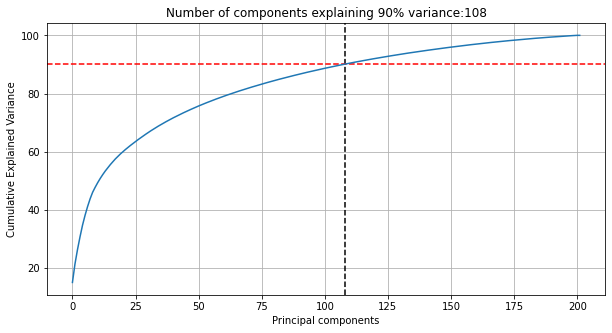

In [ ]:
plt.figure(figsize=[10,5])
plt.title("Number of components explaining 90% variance:" + str(selected_features_pca))
plt.ylabel("Cumulative Explained Variance")
plt.xlabel("Principal components")
plt.axvline(x=selected_features_pca, color='k', linestyle="--")
plt.axhline(y=90, color='r', linestyle="--")
plt.grid()
ax = plt.plot(var_cum)

In [ ]:
n_PCA_components = 108
pca = PCA(n_components=n_PCA_components)
train_PCA = pca.fit_transform(X_train)
test_PCA = pca.transform(X_test)

In [ ]:
train_PCA.shape, test_PCA.shape

((202, 108), (87, 108))

In [ ]:
pca.explained_variance_ratio_

array([0.15096342, 0.06329816, 0.04942843, 0.04389325, 0.04026403,
       0.03379325, 0.03006757, 0.02650121, 0.02255341, 0.01710605,
       0.01583183, 0.01448254, 0.01325652, 0.01229806, 0.01114956,
       0.01085991, 0.00993859, 0.00968143, 0.00875652, 0.00831771,
       0.00774253, 0.00755859, 0.00715304, 0.00695537, 0.00668134,
       0.00665225, 0.0064509 , 0.00622967, 0.00616295, 0.00602397,
       0.0058868 , 0.00575948, 0.00552775, 0.00543207, 0.00529136,
       0.00504822, 0.00501392, 0.00487639, 0.00476993, 0.00468504,
       0.00449875, 0.00438612, 0.00433149, 0.00421973, 0.00418461,
       0.00407675, 0.00396934, 0.00390841, 0.00388298, 0.00386098,
       0.00364924, 0.00362771, 0.0035258 , 0.00350409, 0.00340951,
       0.00337858, 0.00334072, 0.00326537, 0.00320239, 0.0031819 ,
       0.00308738, 0.0030774 , 0.00299849, 0.00296196, 0.00293853,
       0.00288093, 0.00283624, 0.00278914, 0.00272478, 0.00270901,
       0.00267592, 0.00265748, 0.00259048, 0.00256622, 0.00255

In [ ]:
pca.explained_variance_ratio_.sum()

0.8979325739408917

In [ ]:
n_pcs= pca.components_.shape[0]

# get the index of the most important feature on EACH component i.e. largest absolute value
# using LIST COMPREHENSION HERE
most_important = [np.abs(pca.components_[i]).argmax() for i in range(n_pcs)]

initial_feature_names = X.columns

# get the names
most_important_names = [initial_feature_names[most_important[i]] for i in range(n_pcs)]

# using LIST COMPREHENSION HERE AGAIN
dic = {'PC{}'.format(i+1): most_important_names[i] for i in range(n_pcs)}

# build the dataframe
df_PCA = pd.DataFrame(sorted(dic.items()))
df_PCA.columns=['Principal Components','Important Feature']

In [ ]:
df_PCA.head()

,Principal Components,Important Feature
0,PC1,NR_038344
1,PC10,NM_020894
2,PC100,NR_024457
3,PC101,ENST00000489000
4,PC102,NM_001042475


In [ ]:
features_names_by_PCA = df_PCA['Important Feature'].values

In [ ]:
len(features_names_by_PCA)

108

### Mutual Information

In [ ]:
#Calculate the MI
mi = mutual_info_classif(X_train, y_train)

In [ ]:
len(mi)

16382

In [ ]:
mi

array([0.00770485, 0.02827685, 0.10922354, ..., 0.        , 0.0271493 ,
       0.        ])

In [ ]:
sel = SelectPercentile(mutual_info_classif, percentile=5).fit(X, y)

In [ ]:
features_selected_by_MI = X.columns[sel.get_support(indices=True)]

In [ ]:
len(features_selected_by_MI)

820

### LASSO

In [ ]:
scaler_1 = StandardScaler()
X_scld = scaler_1.fit_transform(X)

In [ ]:
#Lasso
from sklearn.linear_model import LassoCV

In [ ]:
lcv = LassoCV(n_jobs=-1, verbose=1)

In [ ]:
lcv.fit(X_scld, y)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
....................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  2.3min finished


LassoCV(n_jobs=-1, verbose=1)

In [ ]:
print(lcv.alpha_)

0.016430728337079308


In [ ]:
lcv.score(X_test, y_test)

0.9173728725903179

In [ ]:
lcv_mask = lcv.coef_!=0

In [ ]:
print(lcv_mask)

[False False False ... False False False]


In [ ]:
reduced_X = X.loc[:, lcv_mask]

In [ ]:
reduced_X.columns

Index(['ERCC-00071_128', 'lincRNA:chr12:59990908-60003558_R', 'NR_024062',
       'NM_014966', 'NM_003886', 'NM_001007471', 'NM_001100917',
       'lincRNA:chr11:117668490-117680359_R', 'ENST00000557073', 'NM_004426',
       ...
       'NM_153708', 'NM_001113523', 'NM_001083926',
       'lincRNA:chr6:138145796-138182040_R', 'NM_152725', 'NM_001142285',
       'ENST00000368582', 'THC2537731', 'NM_006653', 'NR_036446'],
      dtype='object', length=143)

In [ ]:
selected_features_lasso = reduced_X.columns

In [ ]:
len(selected_features_lasso)

143

### FINAL Result

In [ ]:
features=sorted(df.drop('type',axis=1).columns)

In [ ]:
df.head()

,type,NM_144987,NM_013290,ENST00000322831,NM_001625,lincRNA:chr7:226042-232442_R,NM_032391,ENST00000238571,XR_108906,NM_005937,...,NM_207327,NM_001004477,NM_020700,NM_005895,NM_000679,NR_003529,NR_036446,NM_001001957,lincRNA:chr7:29652000-29661000_R,ENST00000494108
0,0,8.693318,7.718016,6.044438,10.747077,9.133777,4.735581,5.634732,4.670231,11.152649,...,10.453202,4.376090,5.597596,11.860087,11.321528,4.486530,5.489959,5.810069,4.834056,4.383929
1,0,9.375980,7.072232,6.976741,10.429671,9.526500,5.221089,5.425187,4.860931,10.839289,...,10.066372,4.383785,5.404546,11.636828,8.283747,4.770318,5.345571,4.457930,4.441395,4.411587
2,0,8.943442,7.964573,6.269055,10.825025,9.396855,5.258506,5.824921,4.964604,10.884157,...,10.380676,4.428892,5.356374,12.031338,9.420630,4.394069,5.851030,4.508072,4.568262,4.316081
3,0,9.020798,7.824639,6.165165,11.646788,8.776462,4.648655,6.676692,4.770186,10.646459,...,10.509871,4.381542,5.757179,11.944607,10.311339,4.451118,6.117379,4.505663,4.413361,4.537626
4,0,8.806154,7.555348,6.230969,11.635247,8.911383,4.518054,6.520691,4.540453,10.939783,...,10.552841,4.386116,6.851058,11.976510,10.904219,4.432566,6.286439,4.540453,4.412933,4.452250


In [ ]:
# Putting all selections together
def get_true_false(selected_features, features):
    selected_t_f = []
    for feature in features:
        if feature in selected_features:
            selected_t_f.append(True)
        else:
            selected_t_f.append(False)
    return selected_t_f

In [ ]:
features = sorted(df.drop('type', axis=1).columns)
df_selections = pd.DataFrame({'Feature': features,
                              'PCA': get_true_false(features_names_by_PCA, features),
                              'Information Gain': get_true_false(features_selected_by_MI, features),
                              'Lasso': get_true_false(selected_features_lasso, features)})
df_selections['Total'] = np.sum(df_selections, axis=1)
df_selections = df_selections.sort_values(['Total', 'Feature'], ascending=False)
df_selections.index = range(1, len(df_selections) + 1)


In [ ]:
df_selections[:10]

,Feature,PCA,Information Gain,Lasso,Total
1,lincRNA:chr11:117668490-117680359_R,False,True,True,2
2,NR_038344,True,True,False,2
3,NM_138764,False,True,True,2
4,NM_025009,False,True,True,2
5,NM_007225,False,True,True,2
6,NM_007174,False,True,True,2
7,NM_006101,False,True,True,2
8,NM_001361,False,True,True,2
9,NM_001049,False,True,True,2
10,NM_000088,False,True,True,2


In [ ]:
final_selected = list(df_selections[df_selections['Total'] > 1]['Feature'])

In [ ]:
final_selected

['lincRNA:chr11:117668490-117680359_R',
 'NR_038344',
 'NM_138764',
 'NM_025009',
 'NM_007225',
 'NM_007174',
 'NM_006101',
 'NM_001361',
 'NM_001049',
 'NM_000088',
 'ENST00000497634',
 'ENST00000468376',
 'ENST00000397648',
 'A_33_P3374982']

In [ ]:
len(final_selected)

14

In [ ]:
df = df[final_selected]
X = df.values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='entropy', random_state=0)
dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [ ]:
y_pred = dt.predict(X_test)

In [ ]:
from sklearn import metrics
from sklearn.metrics import confusion_matrix

#Generate the confusion matrix
cf_matrix = confusion_matrix(y_test, y_pred)

print('confusion matrix:\n', cf_matrix)
print('accuracy:', metrics.accuracy_score(y_test, y_pred))
print('precision:', metrics.precision_score(y_test, y_pred))
print('recall:', metrics.recall_score(y_test, y_pred))
print('f1-score:', metrics.f1_score(y_test, y_pred))
print(metrics.classification_report(y_test, y_pred))

confusion matrix:
 [[38  8]
 [ 6 35]]
accuracy: 0.8390804597701149
precision: 0.813953488372093
recall: 0.8536585365853658
f1-score: 0.8333333333333333
              precision    recall  f1-score   support

           0       0.86      0.83      0.84        46
           1       0.81      0.85      0.83        41

    accuracy                           0.84        87
   macro avg       0.84      0.84      0.84        87
weighted avg       0.84      0.84      0.84        87



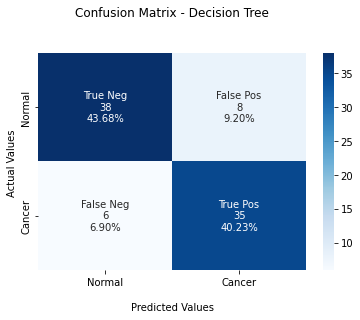

In [ ]:
import seaborn as sns

group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cf_matrix.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cf_matrix.flatten()/np.sum(cf_matrix)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)
ax = sns.heatmap(cf_matrix, annot=labels, fmt='', cmap='Blues')
ax.set_title('Confusion Matrix - Decision Tree\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['Normal','Cancer'])
ax.yaxis.set_ticklabels(['Normal','Cancer'])

## Display the visualization of the Confusion Matrix.
plt.show()

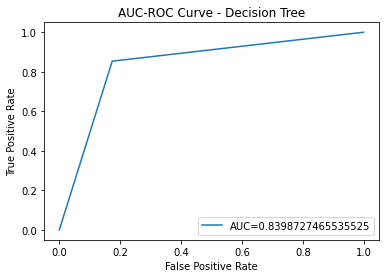

In [ ]:
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred)
auc = metrics.roc_auc_score(y_test, y_pred)

#create ROC curve
plt.plot(fpr,tpr,label="AUC="+str(auc))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title('AUC-ROC Curve - Decision Tree')
plt.legend(loc=4)
plt.show()

# Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_pred = classifier.predict(X_test)

In [ ]:
from sklearn import metrics
from sklearn.metrics import confusion_matrix

#Generate the confusion matrix
cf_matrix = confusion_matrix(y_test, y_pred)

print('confusion matrix:\n', cf_matrix)
print('accuracy:', metrics.accuracy_score(y_test, y_pred))
print('precision:', metrics.precision_score(y_test, y_pred))
print('recall:', metrics.recall_score(y_test, y_pred))
print('f1-score:', metrics.f1_score(y_test, y_pred))
print(metrics.classification_report(y_test, y_pred))

confusion matrix:
 [[39  7]
 [ 6 35]]
accuracy: 0.8505747126436781
precision: 0.8333333333333334
recall: 0.8536585365853658
f1-score: 0.8433734939759037
              precision    recall  f1-score   support

           0       0.87      0.85      0.86        46
           1       0.83      0.85      0.84        41

    accuracy                           0.85        87
   macro avg       0.85      0.85      0.85        87
weighted avg       0.85      0.85      0.85        87



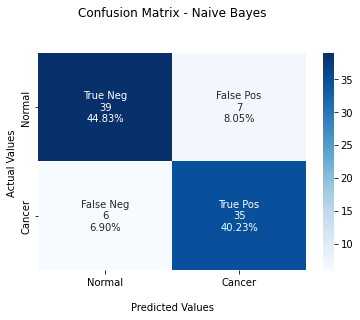

In [ ]:
import seaborn as sns

group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cf_matrix.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cf_matrix.flatten()/np.sum(cf_matrix)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)
ax = sns.heatmap(cf_matrix, annot=labels, fmt='', cmap='Blues')
ax.set_title('Confusion Matrix - Naive Bayes\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['Normal','Cancer'])
ax.yaxis.set_ticklabels(['Normal','Cancer'])

## Display the visualization of the Confusion Matrix.
plt.show()

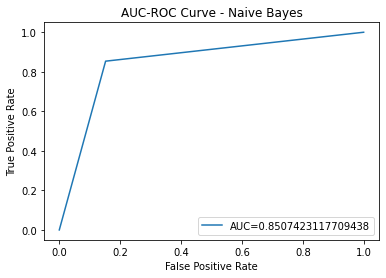

In [ ]:
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred)
auc = metrics.roc_auc_score(y_test, y_pred)

#create ROC curve
plt.plot(fpr,tpr,label="AUC="+str(auc))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title('AUC-ROC Curve - Naive Bayes')
plt.legend(loc=4)
plt.show()

# Support Vector Machine

In [ ]:
from sklearn.svm import SVC, LinearSVC
# classifier = LinearSVC()
classifier = SVC(kernel='linear')
classifier.fit(X_train, y_train)

SVC(kernel='linear')

In [ ]:
y_pred = classifier.predict(X_test)

In [ ]:
from sklearn import metrics
from sklearn.metrics import confusion_matrix

#Generate the confusion matrix
cf_matrix = confusion_matrix(y_test, y_pred)

print('confusion matrix:\n', cf_matrix)
print('accuracy:', metrics.accuracy_score(y_test, y_pred))
print('precision:', metrics.precision_score(y_test, y_pred))
print('recall:', metrics.recall_score(y_test, y_pred))
print('f1-score:', metrics.f1_score(y_test, y_pred))
print(metrics.classification_report(y_test, y_pred))

confusion matrix:
 [[39  7]
 [ 4 37]]
accuracy: 0.8735632183908046
precision: 0.8409090909090909
recall: 0.9024390243902439
f1-score: 0.8705882352941177
              precision    recall  f1-score   support

           0       0.91      0.85      0.88        46
           1       0.84      0.90      0.87        41

    accuracy                           0.87        87
   macro avg       0.87      0.88      0.87        87
weighted avg       0.88      0.87      0.87        87



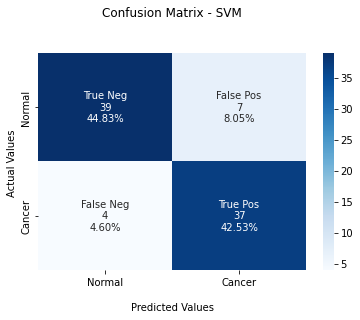

In [ ]:
import seaborn as sns

group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cf_matrix.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cf_matrix.flatten()/np.sum(cf_matrix)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)
ax = sns.heatmap(cf_matrix, annot=labels, fmt='', cmap='Blues')
ax.set_title('Confusion Matrix - SVM\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['Normal','Cancer'])
ax.yaxis.set_ticklabels(['Normal','Cancer'])

## Display the visualization of the Confusion Matrix.
plt.show()

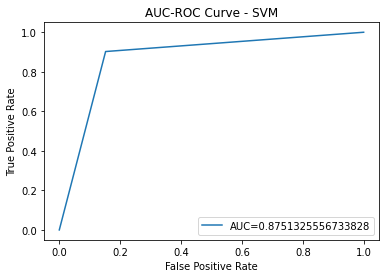

In [ ]:
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred)
auc = metrics.roc_auc_score(y_test, y_pred)

#create ROC curve
plt.plot(fpr,tpr,label="AUC="+str(auc))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title('AUC-ROC Curve - SVM')
plt.legend(loc=4)
plt.show()

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, criterion='gini', random_state=0)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=0)

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [10, 40, 100],
    'max_features': [2, 'sqrt'],
    'min_samples_leaf': [1, 3, 6, 14],
    'min_samples_split': [2, 6, 14],
    'n_estimators': [100]
}
grid = GridSearchCV(RandomForestClassifier(), param_grid, verbose=3)
grid.fit(X_train, y_train)
print(grid.best_params_)
print(grid.best_estimator_)
y_pred = grid.predict(X_test)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
[CV 1/5] END criterion=gini, max_depth=10, max_features=2, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.976 total time=   0.2s
[CV 2/5] END criterion=gini, max_depth=10, max_features=2, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.829 total time=   0.2s
[CV 3/5] END criterion=gini, max_depth=10, max_features=2, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.875 total time=   0.2s
[CV 4/5] END criterion=gini, max_depth=10, max_features=2, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.900 total time=   0.2s
[CV 5/5] END criterion=gini, max_depth=10, max_features=2, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.900 total time=   0.2s
[CV 1/5] END criterion=gini, max_depth=10, max_features=2, min_samples_leaf=1, min_samples_split=6, n_estimators=100;, score=0.976 total time=   0.2s
[CV 2/5] END criterion=gini, max_dept

In [ ]:
from sklearn import metrics
from sklearn.metrics import confusion_matrix

#Generate the confusion matrix
cf_matrix = confusion_matrix(y_test, y_pred)

print('confusion matrix:\n', cf_matrix)
print('accuracy:', metrics.accuracy_score(y_test, y_pred))
print('precision:', metrics.precision_score(y_test, y_pred))
print('recall:', metrics.recall_score(y_test, y_pred))
print('f1-score:', metrics.f1_score(y_test, y_pred))
print(metrics.classification_report(y_test, y_pred))

confusion matrix:
 [[39  7]
 [ 4 37]]
accuracy: 0.8735632183908046
precision: 0.8409090909090909
recall: 0.9024390243902439
f1-score: 0.8705882352941177
              precision    recall  f1-score   support

           0       0.91      0.85      0.88        46
           1       0.84      0.90      0.87        41

    accuracy                           0.87        87
   macro avg       0.87      0.88      0.87        87
weighted avg       0.88      0.87      0.87        87



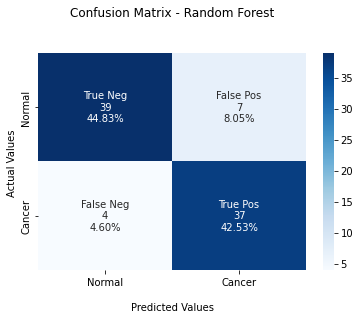

In [ ]:
import seaborn as sns

group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cf_matrix.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cf_matrix.flatten()/np.sum(cf_matrix)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)
ax = sns.heatmap(cf_matrix, annot=labels, fmt='', cmap='Blues')
ax.set_title('Confusion Matrix - Random Forest\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['Normal','Cancer'])
ax.yaxis.set_ticklabels(['Normal','Cancer'])

## Display the visualization of the Confusion Matrix.
plt.show()

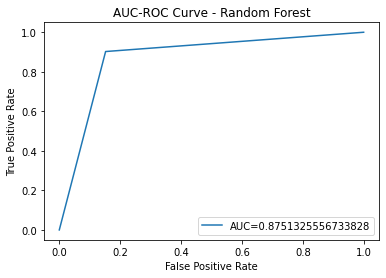

In [ ]:
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred)
auc = metrics.roc_auc_score(y_test, y_pred)

#create ROC curve
plt.plot(fpr,tpr,label="AUC="+str(auc))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title('AUC-ROC Curve - Random Forest')
plt.legend(loc=4)
plt.show()